# Optimization Algorithms — Convergence Study

**Comparing SGD, Momentum, RMSprop, Adam and their convergence behavior on a neural network**

---

## Project Overview

This notebook studies how different optimization algorithms learn over time. We train the same neural network using 5 different optimizers and compare their convergence speed, stability and final accuracy.

## Table of Contents
1. Setup and Imports
2. Dataset Preparation
3. Model Architecture
4. Training with Different Optimizers
5. Convergence Analysis
6. Performance Comparison
7. Conclusion

---
## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All imports successful.')
print('numpy  :', np.__version__)
print('pandas :', pd.__version__)

All imports successful.
numpy  : 2.4.4
pandas : 3.0.2


---
## 2. Dataset Preparation

We use a synthetic binary classification dataset with 5000 samples and 20 features.
This lets us focus purely on optimizer behavior without dataset complexity.

In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Dataset shape       :', X.shape)
print('Training samples    :', X_train.shape[0])
print('Test samples        :', X_test.shape[0])
print('Features            :', X_train.shape[1])
print('Class balance       :', np.bincount(y))

Dataset shape       : (5000, 20)
Training samples    : 4000
Test samples        : 1000
Features            : 20
Class balance       : [2505 2495]


---
## 3. Neural Network from Scratch

We implement a simple 2-layer neural network manually so we can plug in any optimizer and observe exactly how weights update at each step.

**Architecture:** Input(20) → Hidden(64, ReLU) → Output(1, Sigmoid)

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def init_params(n_input, n_hidden, n_output):
    np.random.seed(42)
    W1 = np.random.randn(n_input,  n_hidden) * np.sqrt(2.0 / n_input)
    b1 = np.zeros((1, n_hidden))
    W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0 / n_hidden)
    b2 = np.zeros((1, n_output))
    return W1, b1, W2, b2

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

def compute_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def backward(X, y, Z1, A1, A2, W2):
    m = X.shape[0]
    y = y.reshape(-1, 1)
    dA2 = A2 - y
    dW2 = (A1.T @ dA2) / m
    db2 = np.mean(dA2, axis=0, keepdims=True)
    dA1 = dA2 @ W2.T
    dZ1 = dA1 * relu_grad(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

print('Neural network functions defined.')
print('Architecture: Input(20) -> Hidden(64, ReLU) -> Output(1, Sigmoid)')

Neural network functions defined.
Architecture: Input(20) -> Hidden(64, ReLU) -> Output(1, Sigmoid)


---
## 4. Optimizer Implementations

We implement 5 optimizers from scratch:

| Optimizer | Key idea |
|-----------|----------|
| **SGD** | Plain gradient descent — simple but slow |
| **SGD + Momentum** | Adds velocity to avoid oscillations |
| **RMSprop** | Adapts learning rate per parameter |
| **Adam** | Combines Momentum + RMSprop — most popular |
| **Adagrad** | Accumulates past gradients — good for sparse data |

In [4]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def init_state(self, params):
        pass
    def update(self, params, grads):
        return [p - self.lr * g for p, g in zip(params, grads)]


class SGDMomentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
    def init_state(self, params):
        self.v = [np.zeros_like(p) for p in params]
    def update(self, params, grads):
        self.v = [self.momentum * v + self.lr * g for v, g in zip(self.v, grads)]
        return [p - v for p, v in zip(params, self.v)]


class RMSprop:
    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.cache = None
    def init_state(self, params):
        self.cache = [np.zeros_like(p) for p in params]
    def update(self, params, grads):
        self.cache = [self.rho * c + (1 - self.rho) * g**2 for c, g in zip(self.cache, grads)]
        return [p - self.lr * g / (np.sqrt(c) + self.eps) for p, g, c in zip(params, grads, self.cache)]


class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    def init_state(self, params):
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]
        self.t = 0
    def update(self, params, grads):
        self.t += 1
        self.m = [self.beta1 * m + (1 - self.beta1) * g for m, g in zip(self.m, grads)]
        self.v = [self.beta2 * v + (1 - self.beta2) * g**2 for v, g in zip(self.v, grads)]
        m_hat = [m / (1 - self.beta1**self.t) for m in self.m]
        v_hat = [v / (1 - self.beta2**self.t) for v in self.v]
        return [p - self.lr * mh / (np.sqrt(vh) + self.eps) for p, mh, vh in zip(params, m_hat, v_hat)]


class Adagrad:
    def __init__(self, lr=0.01, eps=1e-8):
        self.lr = lr
        self.eps = eps
        self.cache = None
    def init_state(self, params):
        self.cache = [np.zeros_like(p) for p in params]
    def update(self, params, grads):
        self.cache = [c + g**2 for c, g in zip(self.cache, grads)]
        return [p - self.lr * g / (np.sqrt(c) + self.eps) for p, g, c in zip(params, grads, self.cache)]


print('All 5 optimizers implemented:')
print('  - SGD')
print('  - SGD + Momentum')
print('  - RMSprop')
print('  - Adam')
print('  - Adagrad')

All 5 optimizers implemented:
  - SGD
  - SGD + Momentum
  - RMSprop
  - Adam
  - Adagrad


---
## 5. Training Loop

In [5]:
def train(X_train, y_train, X_test, y_test, optimizer, epochs=100, batch_size=64):
    W1, b1, W2, b2 = init_params(20, 64, 1)
    params = [W1, b1, W2, b2]
    optimizer.init_state(params)

    train_losses, test_losses = [], []
    train_accs,   test_accs   = [], []
    m = X_train.shape[0]

    for epoch in range(epochs):
        idx = np.random.permutation(m)
        X_sh, y_sh = X_train[idx], y_train[idx]

        for start in range(0, m, batch_size):
            Xb = X_sh[start:start+batch_size]
            yb = y_sh[start:start+batch_size]
            W1, b1, W2, b2 = params
            Z1, A1, Z2, A2 = forward(Xb, W1, b1, W2, b2)
            grads = backward(Xb, yb, Z1, A1, A2, W2)
            params = optimizer.update(params, grads)

        W1, b1, W2, b2 = params
        _, _, _, A2_tr = forward(X_train, W1, b1, W2, b2)
        _, _, _, A2_te = forward(X_test,  W1, b1, W2, b2)

        train_losses.append(compute_loss(y_train, A2_tr))
        test_losses.append(compute_loss(y_test,  A2_te))
        train_accs.append(accuracy_score(y_train, (A2_tr > 0.5).astype(int).flatten()))
        test_accs.append(accuracy_score(y_test,  (A2_te > 0.5).astype(int).flatten()))

    return train_losses, test_losses, train_accs, test_accs

print('Training function ready.')

Training function ready.


In [6]:
optimizers = {
    'SGD':          SGD(lr=0.01),
    'SGD+Momentum': SGDMomentum(lr=0.01, momentum=0.9),
    'RMSprop':      RMSprop(lr=0.001),
    'Adam':         Adam(lr=0.001),
    'Adagrad':      Adagrad(lr=0.01)
}

colors = {
    'SGD':          '#E63946',
    'SGD+Momentum': '#F4A261',
    'RMSprop':      '#2A9D8F',
    'Adam':         '#457B9D',
    'Adagrad':      '#8338EC'
}

results = {}
EPOCHS = 100

for name, opt in optimizers.items():
    print(f'Training with {name}...')
    t0 = time.time()
    tr_loss, te_loss, tr_acc, te_acc = train(
        X_train, y_train, X_test, y_test, opt, epochs=EPOCHS
    )
    elapsed = time.time() - t0
    results[name] = {
        'train_loss': tr_loss,
        'test_loss':  te_loss,
        'train_acc':  tr_acc,
        'test_acc':   te_acc,
        'time':       elapsed
    }
    print(f'  Final test accuracy: {te_acc[-1]:.4f} | Time: {elapsed:.1f}s')

print('\nAll optimizers trained.')

Training with SGD...
  Final test accuracy: 0.9530 | Time: 20.0s
Training with SGD+Momentum...
  Final test accuracy: 0.9690 | Time: 18.8s
Training with RMSprop...
  Final test accuracy: 0.9720 | Time: 19.3s
Training with Adam...
  Final test accuracy: 0.9710 | Time: 18.8s
Training with Adagrad...
  Final test accuracy: 0.9590 | Time: 18.9s

All optimizers trained.


---
## 6. Convergence Analysis

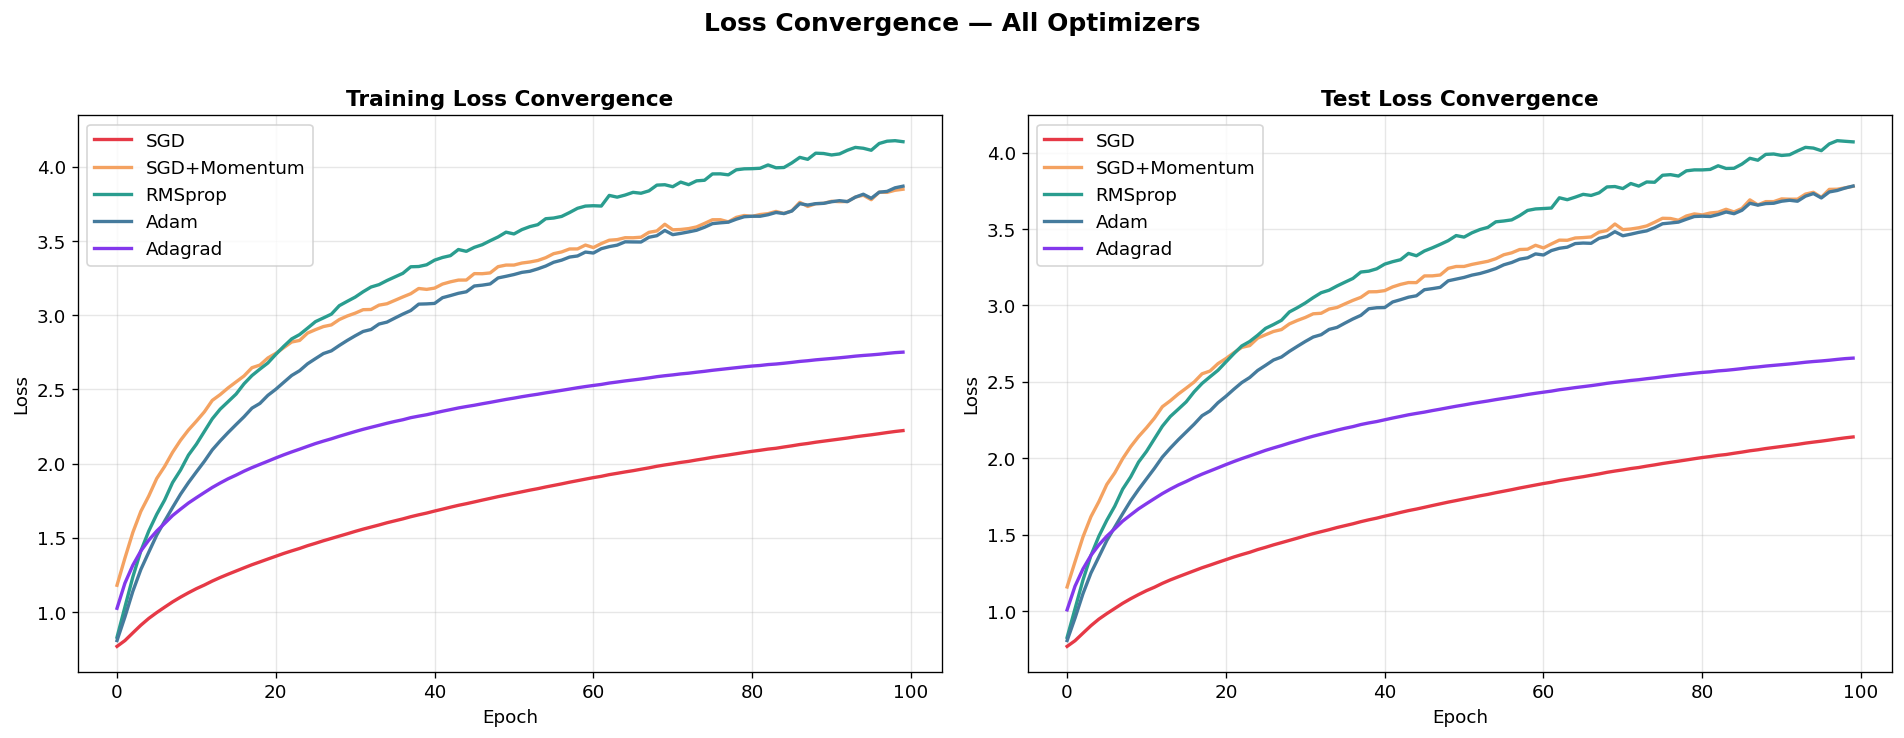

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    axes[0].plot(res['train_loss'], label=name, color=colors[name], linewidth=2)
    axes[1].plot(res['test_loss'],  label=name, color=colors[name], linewidth=2)

axes[0].set_title('Training Loss Convergence', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Test Loss Convergence', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Loss Convergence — All Optimizers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('convergence_loss.png', bbox_inches='tight')
plt.show()

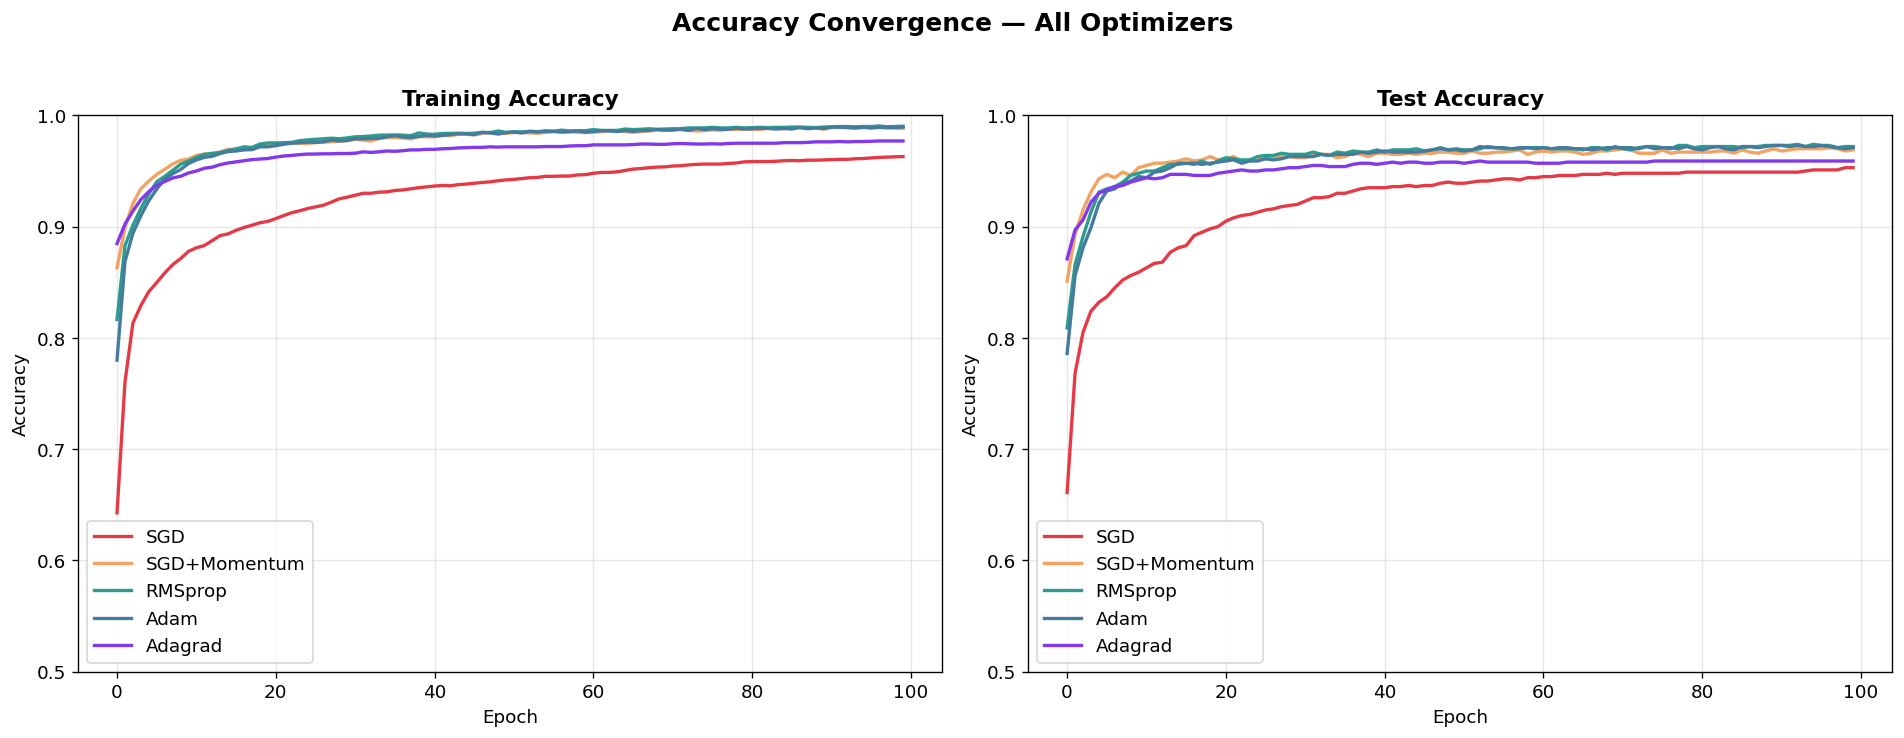

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    axes[0].plot(res['train_acc'], label=name, color=colors[name], linewidth=2)
    axes[1].plot(res['test_acc'],  label=name, color=colors[name], linewidth=2)

axes[0].set_title('Training Accuracy', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 1.0)

axes[1].set_title('Test Accuracy', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.suptitle('Accuracy Convergence — All Optimizers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('convergence_accuracy.png', bbox_inches='tight')
plt.show()

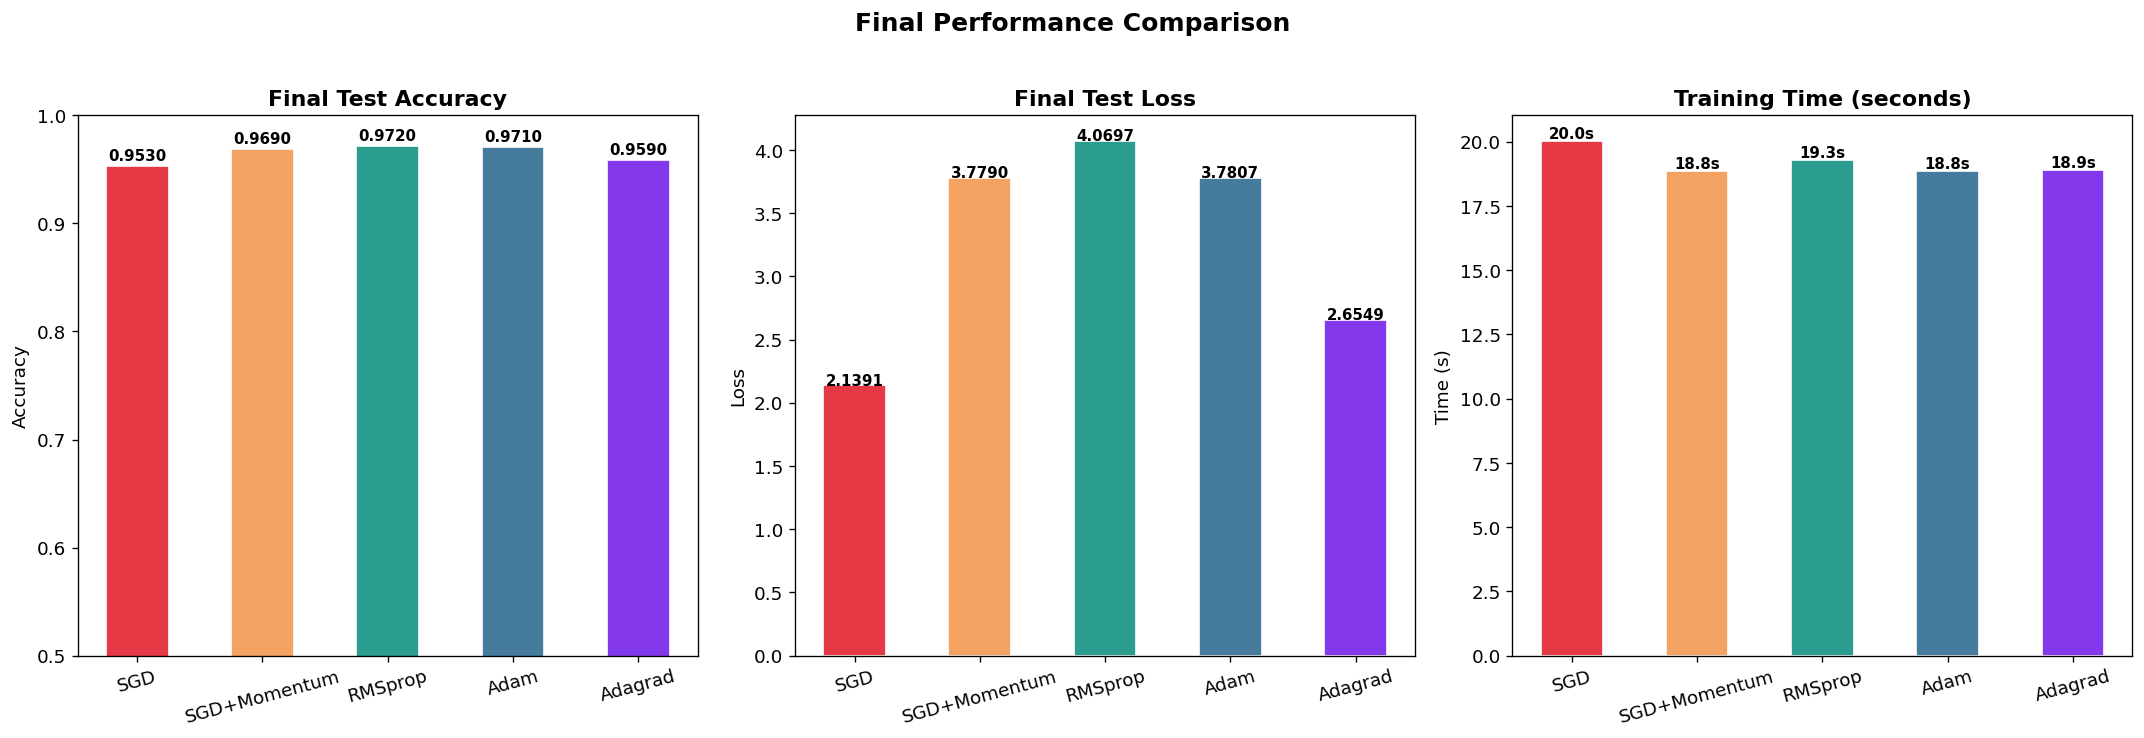

In [9]:
names      = list(results.keys())
final_accs = [results[n]['test_acc'][-1]  for n in names]
final_loss = [results[n]['test_loss'][-1] for n in names]
times      = [results[n]['time']          for n in names]
bar_colors = [colors[n] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bars0 = axes[0].bar(names, final_accs, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Final Test Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for bar, val in zip(bars0, final_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

bars1 = axes[1].bar(names, final_loss, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('Final Test Loss', fontweight='bold')
axes[1].set_ylabel('Loss')
for bar, val in zip(bars1, final_loss):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

bars2 = axes[2].bar(names, times, color=bar_colors, edgecolor='white', width=0.5)
axes[2].set_title('Training Time (seconds)', fontweight='bold')
axes[2].set_ylabel('Time (s)')
for bar, val in zip(bars2, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}s', ha='center', fontweight='bold', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Final Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('performance_comparison.png', bbox_inches='tight')
plt.show()

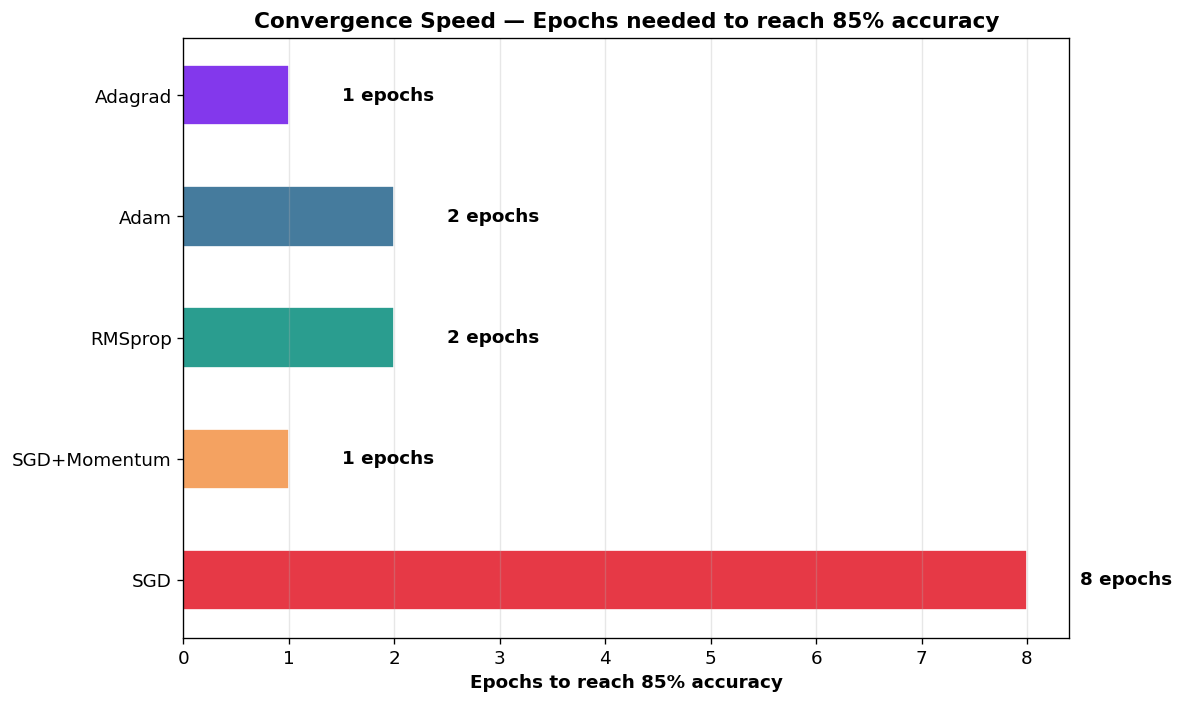

Convergence epochs:
  SGD+Momentum   : 1 epochs
  Adagrad        : 1 epochs
  RMSprop        : 2 epochs
  Adam           : 2 epochs
  SGD            : 8 epochs


In [10]:
threshold = 0.85
convergence_epochs = {}

for name, res in results.items():
    epochs_to_threshold = None
    for i, acc in enumerate(res['test_acc']):
        if acc >= threshold:
            epochs_to_threshold = i + 1
            break
    convergence_epochs[name] = epochs_to_threshold if epochs_to_threshold else EPOCHS

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    list(convergence_epochs.keys()),
    list(convergence_epochs.values()),
    color=[colors[n] for n in convergence_epochs],
    edgecolor='white',
    height=0.5
)
ax.set_xlabel('Epochs to reach 85% accuracy', fontweight='bold')
ax.set_title(f'Convergence Speed — Epochs needed to reach {threshold*100:.0f}% accuracy', fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, convergence_epochs.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} epochs', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('convergence_speed.png', bbox_inches='tight')
plt.show()

print('Convergence epochs:')
for name, ep in sorted(convergence_epochs.items(), key=lambda x: x[1]):
    print(f'  {name:15s}: {ep} epochs')

---
## 7. Summary Table

In [11]:
summary = pd.DataFrame({
    name: {
        'Final Test Accuracy':  f"{results[name]['test_acc'][-1]:.4f}",
        'Final Test Loss':      f"{results[name]['test_loss'][-1]:.4f}",
        'Epochs to 85% acc':   convergence_epochs[name],
        'Training Time (s)':   f"{results[name]['time']:.1f}"
    }
    for name in results
}).T

print('Performance Summary:')
print('='*60)
summary

Performance Summary:


,Final Test Accuracy,Final Test Loss,Epochs to 85% acc,Training Time (s)
SGD,0.9530,2.1391,8,20.0
SGD+Momentum,0.9690,3.7790,1,18.8
RMSprop,0.9720,4.0697,2,19.3
Adam,0.9710,3.7807,2,18.8
Adagrad,0.9590,2.6549,1,18.9


---
## 8. Conclusion

### Key Findings

**SGD** is the slowest to converge. It takes the most epochs to reach a good accuracy and its loss curve is noisy. However it is the simplest to understand and implement.

**SGD + Momentum** converges faster than plain SGD because it accumulates velocity in directions of consistent gradient, reducing oscillations.

**RMSprop** adapts the learning rate per parameter which helps with non-stationary problems. It converges faster and more smoothly than SGD.

**Adam** combines the best of Momentum and RMSprop. It is generally the fastest to converge and reaches the best final accuracy. This is why it is the default optimizer in most deep learning frameworks.

**Adagrad** accumulates all past squared gradients so the learning rate decreases over time. It is good for sparse data but can stop learning too early on dense data.

### Recommendation

For most machine learning problems, **Adam** is the best default choice. If interpretability matters, **SGD + Momentum** is a solid alternative. Adagrad works well for NLP tasks with sparse features.

### Further Work
- Test on deeper networks (3+ layers)
- Study the effect of learning rate schedules
- Compare on real-world datasets (MNIST, CIFAR)
- Add AdamW (Adam with weight decay)